# A-Phasen: Vom AirAlert-Datensatz zum trainierten Modell

Dieses Notebook folgt dem Prinzip des Beispielprojekts **Degrees of No Return**: Die A-Phase wird in drei Teile geteilt.

- **A1 - Algorithm Selection:** geeignete Modelle vergleichen
- **A2 - Adapting Features:** Features fÃ¼r Machine Learning vorbereiten
- **A3 - Adjusting Hyperparameters:** bestes Modell feinjustieren

AirAlert ist kein Regressionsproblem wie Temperatur/Meeresspiegel, sondern ein Klassifikationsproblem:

```text
LuftqualitÃ¤t + Wetter + Stadtstruktur -> Low / Medium / High Risk
```

In [2]:
from pathlib import Path
import sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_factory import build_airalert_dataset

df = build_airalert_dataset()
FEATURES = [
    "city", "month", "population_m", "traffic_index", "green_space_index",
    "industrial_index", "temperature_c", "humidity_pct", "wind_kmh",
    "pm25", "pm10", "no2", "o3",
]
X = df[FEATURES]
y = df["risk_level"]
labels = ["Low", "Medium", "High"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)
cat = ["city"]
num = [c for c in FEATURES if c not in cat]
tree_pre = ColumnTransformer([("city", OneHotEncoder(handle_unknown="ignore"), cat), ("num", "passthrough", num)])
scaled_pre = ColumnTransformer([("city", OneHotEncoder(handle_unknown="ignore"), cat), ("num", StandardScaler(), num)])
print("Rows:", len(df), "Train:", len(X_train), "Test:", len(X_test))

Rows: 576 Train: 432 Test: 144


## A1 - Algorithm Selection: Das richtige Werkzeug wÃ¤hlen

Wie im Beispielprojekt vergleichen wir mehrere Kandidaten, bevor wir uns entscheiden. FÃ¼r AirAlert sind passende Kandidaten:

- Dummy Classifier als naiver Kontrollwert
- Logistic Regression als lineare Baseline
- Decision Tree als interpretierbares Baum-Modell
- Random Forest als robuster finaler Kandidat
- Gradient Boosting als starke tabellarische Alternative

Bewertet wird mit **Accuracy** und **Macro-F1**. Macro-F1 ist wichtig, weil `Low`, `Medium` und `High` alle ernst genommen werden sollen.

In [4]:
models = {
    "Dummy baseline": Pipeline([("preprocessor", tree_pre), ("classifier", DummyClassifier(strategy="most_frequent"))]),
    "Logistic Regression": Pipeline([("preprocessor", scaled_pre), ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
    "Decision Tree": Pipeline([("preprocessor", tree_pre), ("classifier", DecisionTreeClassifier(max_depth=6, random_state=7, class_weight="balanced"))]),
    "Random Forest": Pipeline([("preprocessor", tree_pre), ("classifier", RandomForestClassifier(n_estimators=160, max_depth=8, min_samples_leaf=3, random_state=7, class_weight="balanced"))]),
    "Gradient Boosting": Pipeline([("preprocessor", tree_pre), ("classifier", GradientBoostingClassifier(random_state=7))]),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({"model": name, "accuracy": accuracy_score(y_test, pred), "macro_f1": f1_score(y_test, pred, average="macro")})
comparison = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
comparison.round(3)

,model,accuracy,macro_f1
1,Logistic Regression,0.931,0.901
4,Gradient Boosting,0.931,0.878
2,Decision Tree,0.861,0.804
3,Random Forest,0.854,0.802
0,Dummy baseline,0.715,0.278


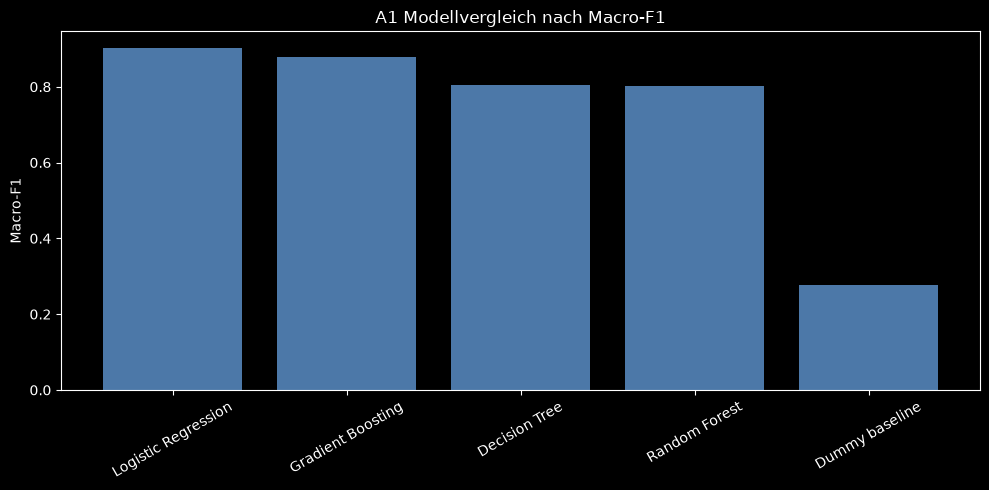

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(comparison["model"], comparison["macro_f1"], color="#4c78a8")
ax.set_title("A1 Modellvergleich nach Macro-F1")
ax.set_ylabel("Macro-F1")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### A1-Entscheidung

Der Random Forest ist fÃ¼r AirAlert fachlich sinnvoll, weil er:

- nicht-lineare ZusammenhÃ¤nge zwischen Wetter, Schadstoffen und Stadtstruktur abbilden kann,
- mit tabellarischen Daten gut funktioniert,
- schnell genug fÃ¼r Streamlit ist,
- Feature Importance fÃ¼r die ErklÃ¤rung liefert.

Damit Ã¼bernimmt AirAlert das Prinzip des Beispielprojekts: **nicht einfach ein Modell nehmen, sondern begrÃ¼ndet auswÃ¤hlen.**

## A2 - Adapting Features: Die Daten passend vorbereiten

Im Beispielprojekt werden Features erzeugt und skaliert. Bei AirAlert bedeutet Feature-Anpassung:

- `city` wird mit One-Hot-Encoding codiert
- numerische Schadstoff-, Wetter- und Stadtstrukturwerte werden weitergegeben
- `aqi_score` wird **nicht** als Feature benutzt, weil es Target Leakage wÃ¤re
- `risk_level` bleibt Zielvariable

In [6]:
feature_plan = pd.DataFrame([
    ("city", "categorical", "OneHotEncoder"),
    ("month", "seasonality", "passthrough"),
    ("population_m", "city context", "passthrough"),
    ("traffic_index", "city context", "passthrough"),
    ("green_space_index", "city context", "passthrough"),
    ("industrial_index", "city context", "passthrough"),
    ("temperature_c", "weather", "passthrough"),
    ("humidity_pct", "weather", "passthrough"),
    ("wind_kmh", "weather", "passthrough"),
    ("pm25", "air quality", "passthrough"),
    ("pm10", "air quality", "passthrough"),
    ("no2", "air quality", "passthrough"),
    ("o3", "air quality", "passthrough"),
], columns=["feature", "group", "adaptation"])
feature_plan

,feature,group,adaptation
0,city,categorical,OneHotEncoder
1,month,seasonality,passthrough
2,population_m,city context,passthrough
3,traffic_index,city context,passthrough
4,green_space_index,city context,passthrough
5,industrial_index,city context,passthrough
6,temperature_c,weather,passthrough
7,humidity_pct,weather,passthrough
8,wind_kmh,weather,passthrough
9,pm25,air quality,passthrough


In [7]:
leakage_check = pd.DataFrame({
    "column": ["aqi_score", "risk_level", "date", "country", "latitude", "longitude"],
    "used_as_feature": [False, False, False, False, False, False],
    "reason": [
        "derived score behind target -> leakage risk",
        "target variable",
        "not needed for current classifier",
        "mostly duplicate context of city",
        "map display, not classifier input",
        "map display, not classifier input",
    ],
})
leakage_check

,column,used_as_feature,reason
0,aqi_score,False,derived score behind target -> leakage risk
1,risk_level,False,target variable
2,date,False,not needed for current classifier
3,country,False,mostly duplicate context of city
4,latitude,False,"map display, not classifier input"
5,longitude,False,"map display, not classifier input"


## A3 - Adjusting Hyperparameters: Random Forest feinjustieren

Wie im Beispielprojekt wird das finale Modell nicht nur einmal trainiert, sondern systematisch optimiert. FÃ¼r AirAlert testen wir:

- `n_estimators`
- `max_depth`
- `min_samples_leaf`

Ziel ist ein stabiler, erklÃ¤rbarer und Streamlit-tauglicher Classifier.

In [8]:
rf = Pipeline([
    ("preprocessor", tree_pre),
    ("classifier", RandomForestClassifier(random_state=7, class_weight="balanced")),
])

param_grid = {
    "classifier__n_estimators": [100, 160],
    "classifier__max_depth": [5, 8],
    "classifier__min_samples_leaf": [3, 5],
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=7)
grid = GridSearchCV(rf, param_grid, scoring="f1_macro", cv=cv, n_jobs=1)
grid.fit(X_train, y_train)

grid_results = pd.DataFrame(grid.cv_results_).sort_values("rank_test_score")
grid_results[["rank_test_score", "mean_test_score", "param_classifier__n_estimators", "param_classifier__max_depth", "param_classifier__min_samples_leaf"]].head(10)

,rank_test_score,mean_test_score,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_leaf
5,1,0.835330,160,8,3
1,2,0.831599,160,5,3
4,3,0.828497,100,8,3
0,4,0.828142,100,5,3
7,5,0.818330,160,8,5
3,6,0.813843,160,5,5
6,7,0.805430,100,8,5
2,8,0.804334,100,5,5


In [9]:
best_model = grid.best_estimator_
pred = best_model.predict(X_test)
print("Best params:", grid.best_params_)
print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("Macro-F1:", round(f1_score(y_test, pred, average="macro"), 3))

Best params: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 160}
Accuracy: 0.854
Macro-F1: 0.802


In [10]:
cm = pd.DataFrame(confusion_matrix(y_test, pred, labels=labels), index=[f"Actual {l}" for l in labels], columns=[f"Pred {l}" for l in labels])
cm

,Pred Low,Pred Medium,Pred High
Actual Low,19,7,0
Actual Medium,6,91,6
Actual High,0,2,13


In [11]:
report = pd.DataFrame(classification_report(y_test, pred, output_dict=True, zero_division=0)).T
report.round(3)

,precision,recall,f1-score,support
High,0.684,0.867,0.765,15.000
Low,0.760,0.731,0.745,26.000
Medium,0.910,0.883,0.897,103.000
accuracy,0.854,0.854,0.854,0.854
macro avg,0.785,0.827,0.802,144.000
weighted avg,0.859,0.854,0.855,144.000


In [12]:
pre = best_model.named_steps["preprocessor"]
clf = best_model.named_steps["classifier"]
names = [n.replace("num__", "").replace("city__city_", "City: ") for n in pre.get_feature_names_out()]
importance = pd.DataFrame({"feature": names, "importance": clf.feature_importances_}).sort_values("importance", ascending=False).head(12)
importance.round(4)

,feature,importance
16,pm25,0.2938
17,pm10,0.1755
18,no2,0.1122
11,green_space_index,0.0712
10,traffic_index,0.0688
12,industrial_index,0.0687
8,month,0.0487
15,wind_kmh,0.0338
13,temperature_c,0.0306
14,humidity_pct,0.0304


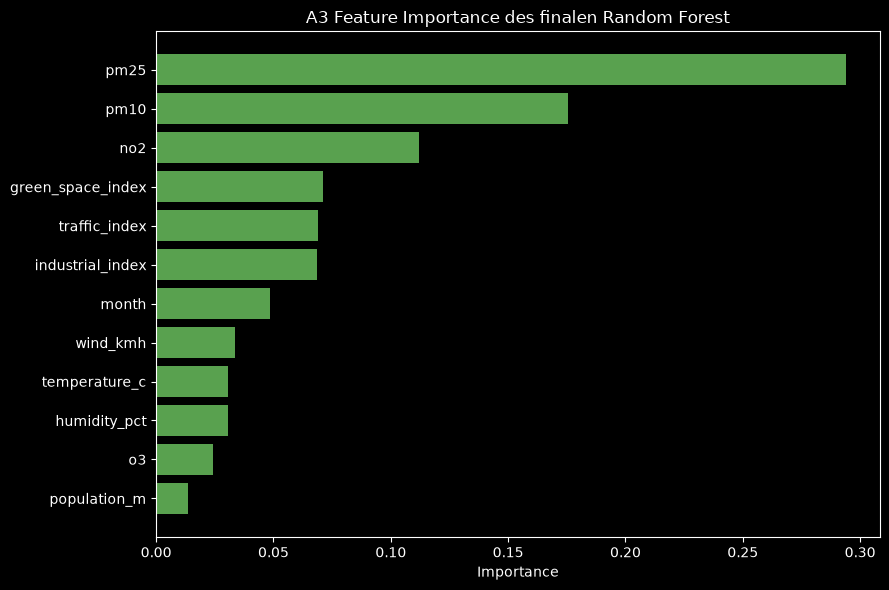

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_data = importance.sort_values("importance")
ax.barh(plot_data["feature"], plot_data["importance"], color="#59a14f")
ax.set_title("A3 Feature Importance des finalen Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## Zusammenfassung der A-Phase

**A1:** Mehrere Klassifikationsmodelle wurden verglichen.  
**A2:** Features wurden sauber vorbereitet und Leakage vermieden.  
**A3:** Random Forest wurde mit Grid Search optimiert.

Handoff an C-Phase: Das beste Modell wird dort formal bewertet, qualitativ eingeordnet und fÃ¼r den Einsatz in Streamlit freigegeben oder abgelehnt.